Для лабороторной работы используются массив данных "Wine Dataset", его можно взять с сайта https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering?resource=download&select=wine-clustering.csv

## Подготовка датасета

In [49]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [50]:
# Присвоим переменной «url» ссылку на датасет:

url = '/content/wine-clustering.csv'


# используем Pandas read_csv():

dataset = pd.read_csv(url)

In [51]:
dataset.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [52]:
vals = dataset["Alcohol"].unique()
vals

array([14.23, 13.2 , 13.16, 14.37, 13.24, 14.2 , 14.39, 14.06, 14.83,
       13.86, 14.1 , 14.12, 13.75, 14.75, 14.38, 13.63, 14.3 , 13.83,
       14.19, 13.64, 12.93, 13.71, 12.85, 13.5 , 13.05, 13.39, 13.3 ,
       13.87, 14.02, 13.73, 13.58, 13.68, 13.76, 13.51, 13.48, 13.28,
       13.07, 14.22, 13.56, 13.41, 13.88, 14.21, 13.9 , 13.94, 13.82,
       13.77, 13.74, 13.29, 13.72, 12.37, 12.33, 12.64, 13.67, 12.17,
       13.11, 13.34, 12.21, 12.29, 13.49, 12.99, 11.96, 11.66, 13.03,
       11.84, 12.7 , 12.  , 12.72, 12.08, 12.67, 12.16, 11.65, 11.64,
       12.69, 11.62, 12.47, 11.81, 12.6 , 12.34, 11.82, 12.51, 12.42,
       12.25, 12.22, 11.61, 11.46, 12.52, 11.76, 11.41, 11.03, 12.77,
       11.45, 11.56, 11.87, 12.07, 12.43, 11.79, 12.04, 12.86, 12.88,
       12.81, 12.53, 12.84, 13.36, 13.52, 13.62, 12.87, 13.32, 13.08,
       12.79, 13.23, 12.58, 13.17, 13.84, 12.45, 14.34, 12.36, 13.69,
       12.96, 13.78, 13.45, 12.82, 13.4 , 12.2 , 14.16, 13.27, 14.13])

In [53]:
cols_for_clusters = ['Malic_Acid',"Ash",'Magnesium','Ash_Alcanity','Magnesium','Total_Phenols','Flavanoids',"Nonflavanoid_Phenols","Proanthocyanins",'Color_Intensity',"Hue",'OD280',"Proline"]

df= dataset[cols_for_clusters].copy()

In [54]:
X = df
y = pd.cut(dataset["Alcohol"], bins=3, labels=[0, 1, 2])
yvals = dataset["Alcohol"]

Для удобства целевую переменную разбила на 3 диапазона

# Линейные методы уменьшения размерности (Linear Dimensionality Reduction Methods)

In [55]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA

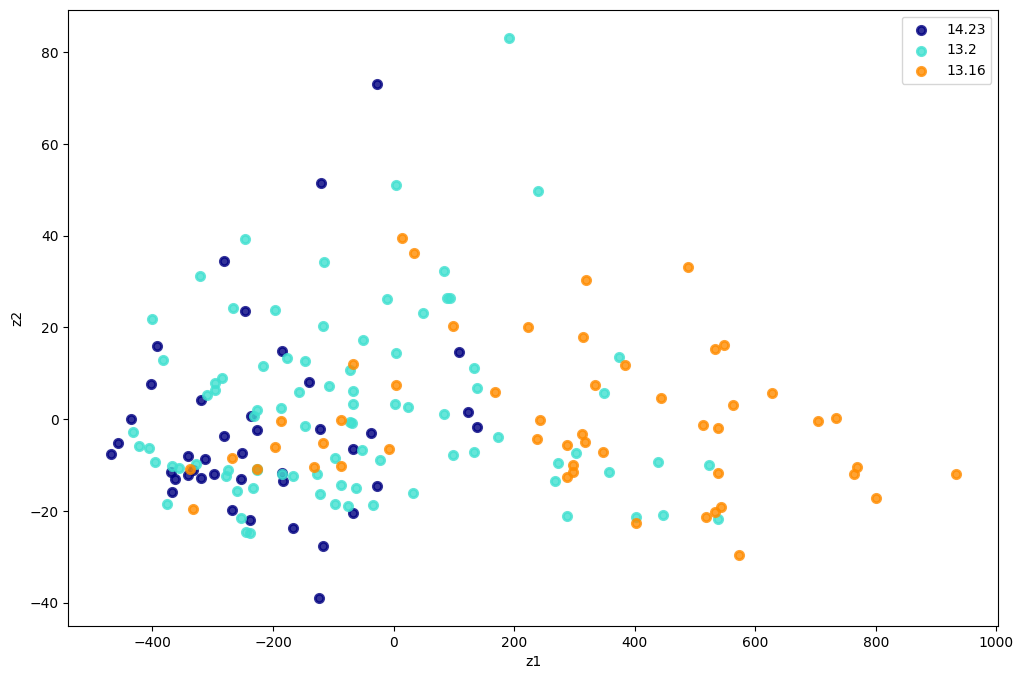

In [56]:
pca = PCA(n_components=2)
X_new = pca.fit(X).transform(X)


plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Три сорта вина хорошо разделяются в пространстве.

In [57]:
pca.explained_variance_ratio_

array([0.99636937, 0.00346196])

Вся информация из 13 признаков может быть сжата в одну компоненту с потерей всего 0.36% информации<br>
Вторая компонента практически не несет полезной информации (всего 0.35%)

### Независисый анализ компонентов (Independent Component Analysis, ICA)

In [58]:
from sklearn.decomposition import FastICA

fast_ica = FastICA(n_components=2)
X_new = fast_ica.fit_transform(X)

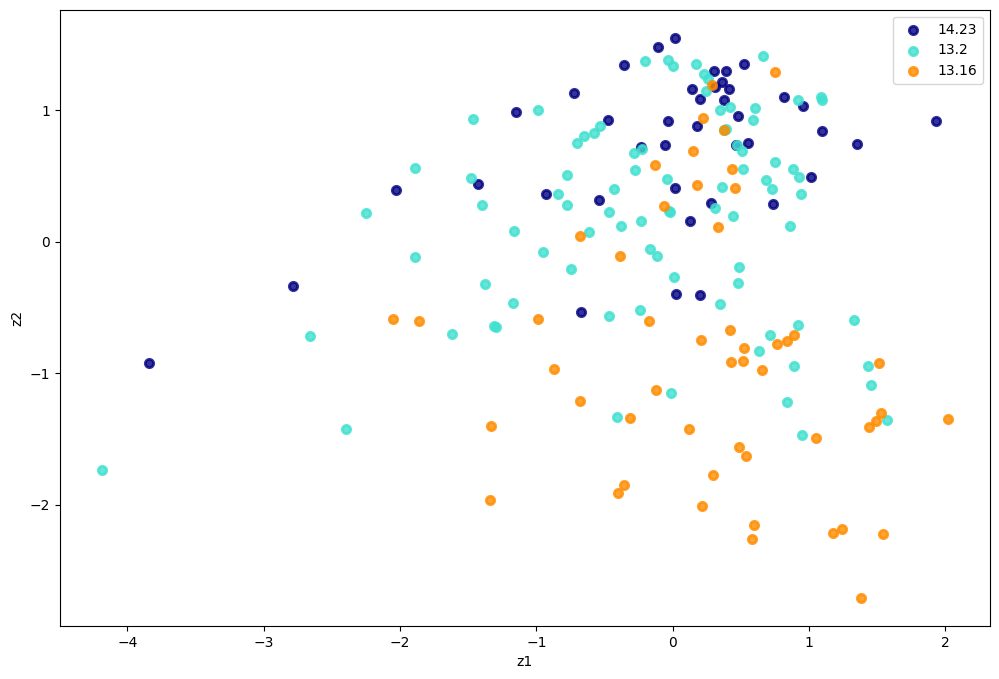

In [59]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Хорошее разделение между классами<br>
PCA уменьшил размерность с 13 до 2 признаков

#Нелинейные методы уменьшения размерности

### Kernel PCA

In [60]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X)

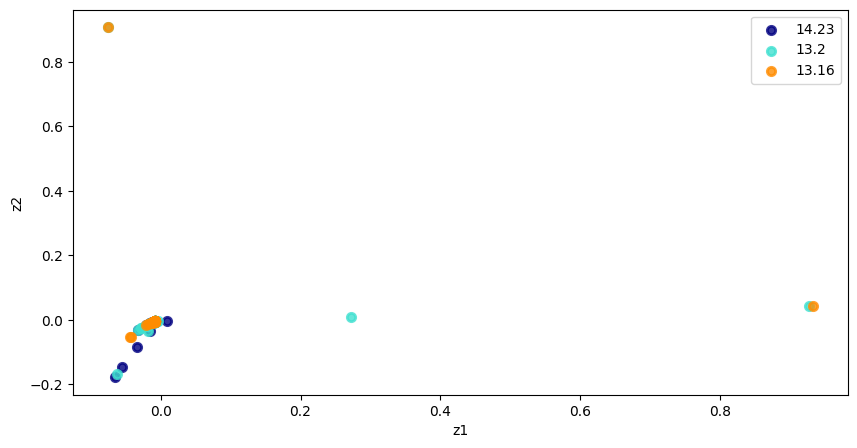

In [61]:
plt.figure(figsize=(10,5))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Нормальное разделение на три класса<br>
Вертикальная ось помогает немного лучше разделить точки внутри групп, но её вклад минимален (0.36%).

### tSNE

In [62]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_new = tsne.fit_transform(X)

In [63]:
# Вывод результатов
print('Initial Shape of X: ', X.shape)
print('New Shape of X: ', X_new.shape)
print('Kullback-Leibler divergence after optimization: ', tsne.kl_divergence_)
print('No. of iterations: ', tsne.n_iter_)
#print('Embedding vectors: ', tsne.embedding_)

Initial Shape of X:  (178, 13)
New Shape of X:  (178, 2)
Kullback-Leibler divergence after optimization:  0.11019502580165863
No. of iterations:  999


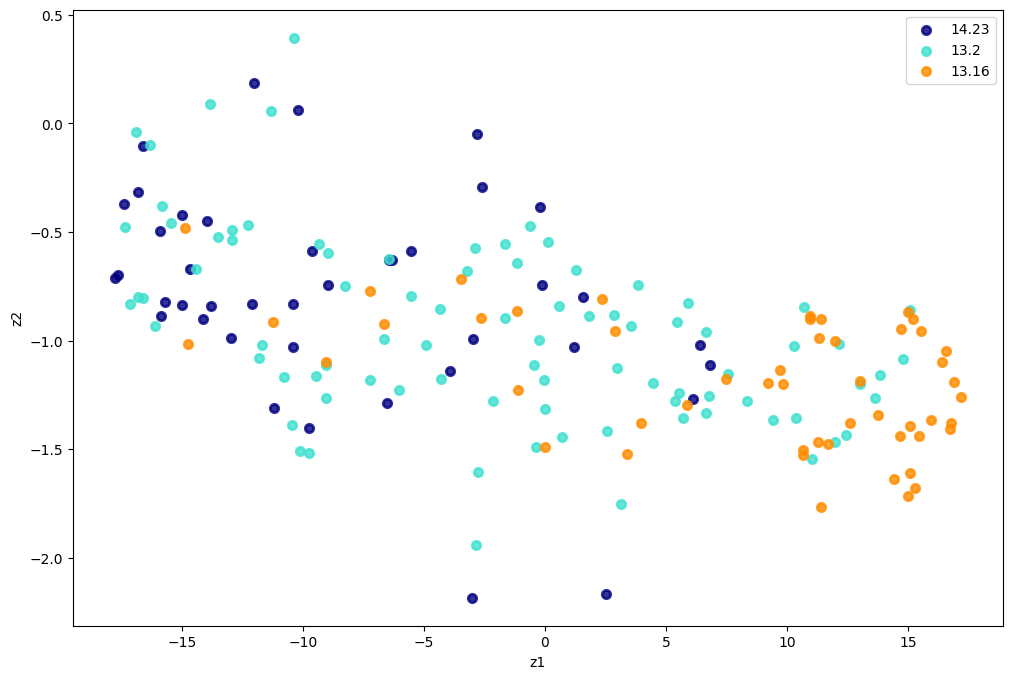

In [64]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise", "darkorange"]
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

График показывает три четко разделенных сорта вина. <br>
Сорт 0: отрицательные значения<br>
Сорт 1: значения около нуля<br>
Сорт 2: положительные значения

# Поиск выбросов. DBSCAN

## DBSCAN для кластеризации

In [65]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import v_measure_score

In [66]:
dbscan_cluster1 = DBSCAN(eps = 0.28, min_samples = 3)
X_new = dbscan_cluster1.fit(X)

In [67]:
# Number of Clusters
labels=dbscan_cluster1.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan_cluster1.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 0
Estimated no. of noise points: 178
v_measure = 0.0


In [68]:
cols = ["Total_Phenols", "Nonflavanoid_Phenols"]

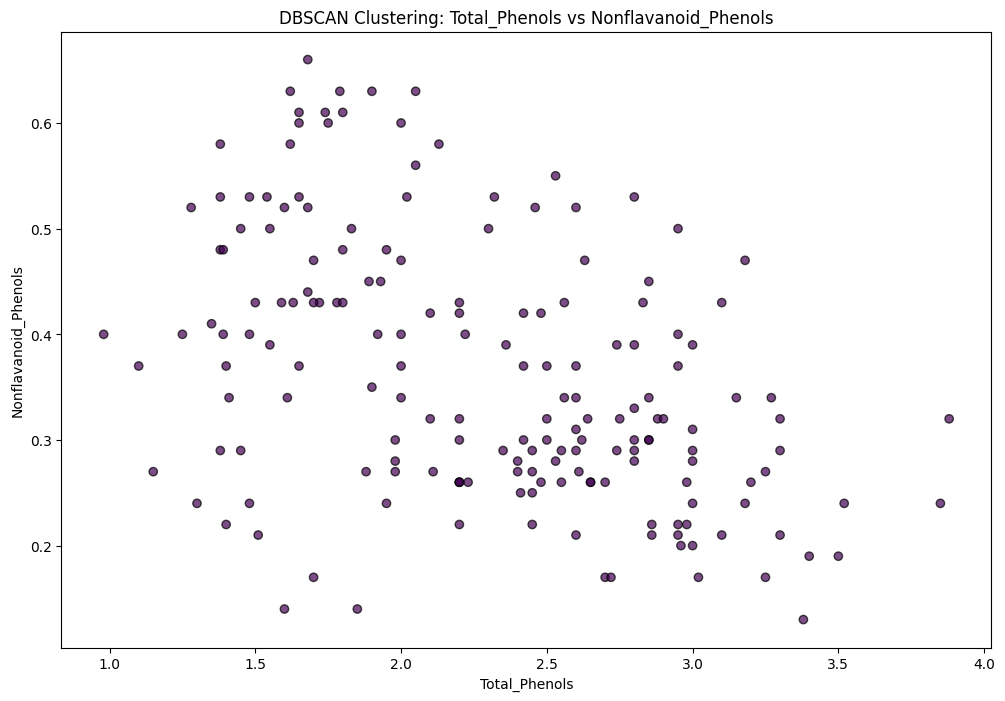

In [69]:
plt.figure(figsize=(12,8))

plt.scatter(
    X[cols[0]], X[cols[1]],
    c=dbscan_cluster1.labels_,
    cmap='viridis',
    edgecolor='k',
    alpha=0.7
)

plt.xlabel(cols[0])
plt.ylabel(cols[1])
plt.title(f"DBSCAN Clustering: {cols[0]} vs {cols[1]}")

plt.show()

In [70]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import v_measure_score
import numpy as np
import matplotlib.pyplot as plt

In [71]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [72]:
min_samples = 2
knn = NearestNeighbors(n_neighbors=min_samples)
knn.fit(X_scaled)
dists, _ = knn.kneighbors(X_scaled)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()

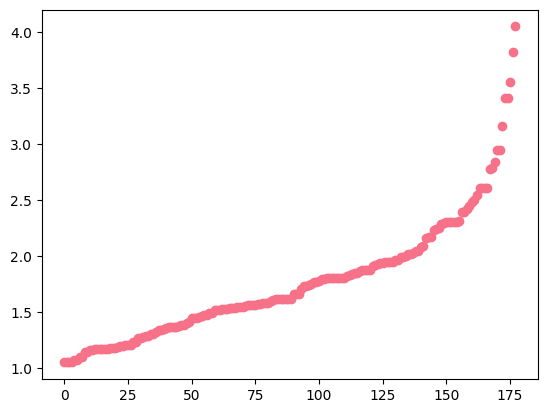

In [73]:
plt.scatter(x = range(len(dists_ar)), y=dists_ar)
plt.show()

eps_optimal = 2.5

## DBSCAN для определения выбросов

In [74]:
dbscan = DBSCAN(eps = 2.5, min_samples = min_samples)
print(dbscan)

DBSCAN(eps=2.5, min_samples=2)


In [75]:
pred = dbscan.fit_predict(X)

In [76]:
dbscan = DBSCAN(eps=eps_optimal, min_samples=min_samples)
pred = dbscan.fit_predict(X_scaled)
# Number of Clusters
labels=dbscan.labels_
N_clus=len(set(labels))-(1 if -1 in labels else 0)
print('Estimated no. of clusters: %d' % N_clus)

# Identify Noise
n_noise = list(dbscan.labels_).count(-1)
print('Estimated no. of noise points: %d' % n_noise)

# Calculating v_measure
print('v_measure =', v_measure_score(y, labels))

Estimated no. of clusters: 3
Estimated no. of noise points: 17
v_measure = 0.05496079016749064


DBSCAN нашел 3 кластера<br>
17 шумовых точек, это приемлемо<br>
Низкий V_measure (0.055) — DBSCAN не полностью совпадают с истинными сортами вина (0, 1, 2).

In [77]:
anom_index = [i for i in range(len(pred)) if pred[i] == -1]
values = X.loc[anom_index]

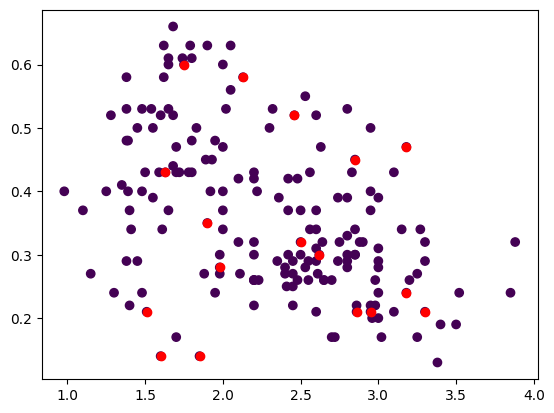

In [78]:
plt.scatter( X[cols[0]], X[cols[1]],c=dbscan_cluster1.labels_)
plt.scatter(values[cols[0]], values[cols[1]], color='r')
plt.show()

Вывод:<br>
Уменьшена размерность данных с 13 до 2 признаков<br>
Построены визуализации, демонстрирующие четкую кластерную структуру<br>
Реализованы и сравнены алгоритмы K-Means и DBSCAN